# 06 — Intervention Outcomes Analysis

**Question:** Which interventions were present in clients who, despite having a high probability of becoming chronically homeless, ultimately did NOT become chronic?

**Context:** We use Model 1 (LightGBM, Phase B) to calculate each client's probability of chronicity at the moment of intake. Clients with score > 0.50 are considered **high risk**. We compare those who avoided chronicity vs those who did become chronic within that group.

**Success criterion:** `became_chronic = 0` — the client never became chronically homeless in any system record.

**Approach:** Descriptive trajectory analysis — which interventions clients had at intake and how they evolved throughout their stay in the system.

**Note:** This analysis shows associations, not causality. Differences between groups may reflect the initial risk profile, not the direct effect of interventions.

## 1. Setup and Data Loading

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import glob
import warnings
warnings.filterwarnings('ignore')

from src.config import PHASE_B_ALL_FEATURES, CAT_FEATURES
from src.data_loader import load_cam

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load training dataset (one record per client, with cut-off filter applied)
df = pd.read_parquet('../data/processed/training_dataset.parquet')
print(f'Training dataset (clients with 6+ months of follow-up): {len(df):,} clients')
print(f'  - Became chronic at some point:  {df["became_chronic"].sum():,} ({df["became_chronic"].mean():.1%})')
print(f'  - Never became chronic:          {(df["became_chronic"]==0).sum():,} ({(df["became_chronic"]==0).mean():.1%})')

# ── Load full CAM data (all snapshots, all clients)
cam = load_cam('../data/raw/D4G_CAM_Final.xlsx')
print(f'\nFull CAM file (all clients): {len(cam):,} snapshots, {cam["Dummy Client ID"].nunique():,} unique clients')
print(f'  Note: includes 542 clients excluded from training (entered the system too recently — less than 6 months of follow-up)')

Training dataset (clients with 6+ months of follow-up): 9,576 clients
  - Became chronic at some point:  3,259 (34.0%)
  - Never became chronic:          6,317 (66.0%)
Loaded CAM: 59,624 rows, 10,118 unique clients

Full CAM file (all clients): 59,624 snapshots, 10,118 unique clients
  Note: includes 542 clients excluded from training (entered the system too recently — less than 6 months of follow-up)


In [3]:
# ── Load Model 1 (Phase B)
m1_files = sorted(glob.glob('../models/phase_b_model1_*.pkl'))
if not m1_files:
    m1_files = sorted(glob.glob('../models/phase_a_baseline_*.pkl'))
model_1 = joblib.load(m1_files[-1])['model']
print(f'Model loaded: {m1_files[-1]}')

# ── Calculate risk score from Model 1 for each client
X = df[PHASE_B_ALL_FEATURES].copy()
for col in CAT_FEATURES:
    if col in X.columns:
        X[col] = X[col].astype('category')

df['risk_score'] = model_1.predict_proba(X)[:, 1]

# ── Define risk bands
df['risk_band'] = pd.cut(
    df['risk_score'],
    bins=[0, 0.32, 0.50, 1.0],
    labels=['Low (<0.32)', 'Medium (0.32-0.50)', 'High (>0.50)']
)

print(f'\nRisk band distribution:')
print(df['risk_band'].value_counts())

Model loaded: ../models/phase_b_model1_20260712.pkl

Risk band distribution:
risk_band
Low (<0.32)           4438
High (>0.50)          3850
Medium (0.32-0.50)    1288
Name: count, dtype: int64


## 2. Time in System Distribution

We calculate how many days each client spent in the system — used as a descriptive variable to compare the two groups.

In [4]:
# ── Calculate time_in_system per client
time_stats = (
    cam.groupby('Dummy Client ID')['Date']
    .agg(['min', 'max'])
    .reset_index()
)
time_stats['time_in_system'] = (time_stats['max'] - time_stats['min']).dt.days

# Merge with main dataframe
df = df.merge(
    time_stats[['Dummy Client ID', 'time_in_system']],
    on='Dummy Client ID',
    how='left'
)

print('Time in system distribution (days):')
print(df['time_in_system'].describe().round(1))
print(f"\n25th percentile: {df['time_in_system'].quantile(0.25):.0f} days")
print(f"Median:          {df['time_in_system'].quantile(0.50):.0f} days")
print(f"75th percentile: {df['time_in_system'].quantile(0.75):.0f} days")
print(f"90th percentile: {df['time_in_system'].quantile(0.90):.0f} days")

Time in system distribution (days):
count    9576.0
mean      180.9
std       214.1
min         0.0
25%        31.0
50%        90.0
75%       214.0
max       790.0
Name: time_in_system, dtype: float64

25th percentile: 31 days
Median:          90 days
75th percentile: 214 days
90th percentile: 550 days


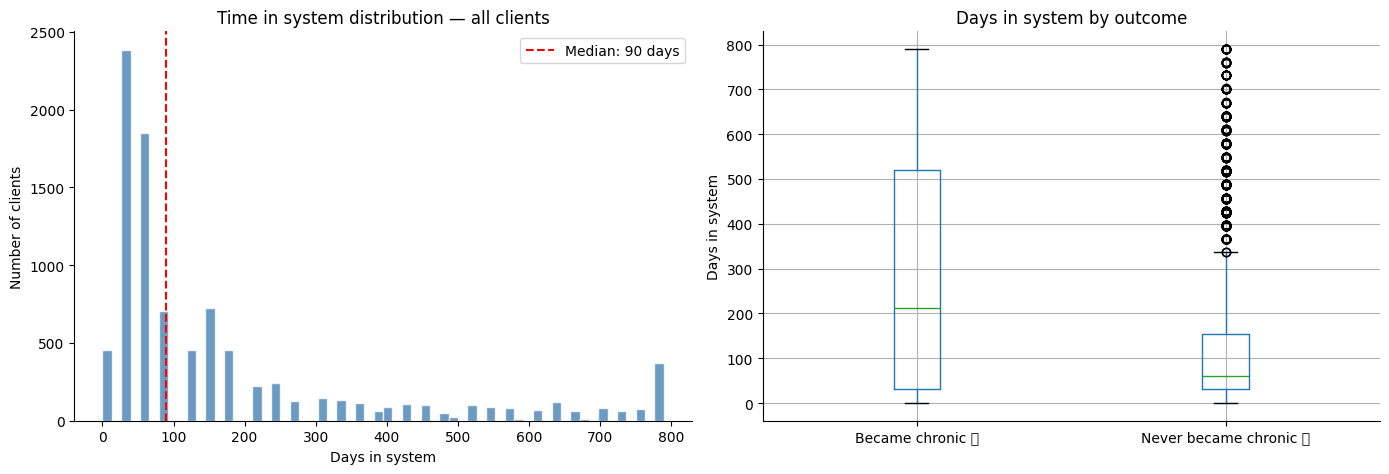


Days in system by outcome:
                 count   mean    std  min   25%    50%    75%    max
became_chronic                                                      
0               6317.0  120.6  140.5  0.0  31.0   61.0  153.0  790.0
1               3259.0  297.7  275.3  0.0  31.0  212.0  519.0  790.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — all clients
axes[0].hist(df['time_in_system'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['time_in_system'].median(), color='red', linestyle='--', label=f"Median: {df['time_in_system'].median():.0f} days")
axes[0].set_xlabel('Days in system')
axes[0].set_ylabel('Number of clients')
axes[0].set_title('Time in system distribution — all clients')
axes[0].legend()

# Boxplot by outcome
df_box = df[['time_in_system', 'became_chronic']].dropna()
df_box['Outcome'] = df_box['became_chronic'].map({0: 'Never became chronic ✅', 1: 'Became chronic ❌'})
df_box.boxplot(column='time_in_system', by='Outcome', ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Days in system')
axes[1].set_title('Days in system by outcome')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('\nDays in system by outcome:')
print(df.groupby('became_chronic')['time_in_system'].describe().round(1))

In [6]:
# ── Define success criterion
# Criterion A: the client never became chronically homeless
df['success_a'] = (df['became_chronic'] == 0).astype(int)

print(f'Clients who never became chronic: {df["success_a"].sum():,} ({df["success_a"].mean():.1%})')

Clients who never became chronic: 6,317 (66.0%)


## 3. Chronicity Rate by Intake Intervention

**Base:** All 9,576 clients in the training dataset (not just high-risk).  
**Purpose:** Overall view — what % of each intervention group eventually became chronic.  
**Important:** The mean risk score shows that interventions are not assigned randomly — SPDAT and Admissions clients have a higher initial risk than G&S or Client Details clients. This table is therefore **not** a direct comparison of effectiveness.

In [7]:
# ── Table: chronicity rate by intake intervention
intake_summary = (
    df.groupby('first_intervention_type')
    .agg(
        n_clients=('became_chronic', 'count'),
        n_chronic=('became_chronic', 'sum'),
        pct_chronic=('became_chronic', 'mean'),
        pct_success_a=('success_a', 'mean'),
        mean_risk_score=('risk_score', 'mean'),
    )
    .sort_values('pct_chronic', ascending=False)
    .reset_index()
)
intake_summary['pct_chronic']      = intake_summary['pct_chronic'].map('{:.1%}'.format)
intake_summary['pct_success_a']    = intake_summary['pct_success_a'].map('{:.1%}'.format)
intake_summary['mean_risk_score']  = intake_summary['mean_risk_score'].map('{:.3f}'.format)

intake_summary.columns = ['Intake intervention', 'N clients', 'N became chronic',
                           '% Became chronic', '% Never became chronic', 'Mean risk score']
print('Chronicity rate by intake intervention:')
print(intake_summary.to_string(index=False))

Chronicity rate by intake intervention:
 Intake intervention  N clients  N became chronic % Became chronic % Never became chronic Mean risk score
               SPDAT         62                44            71.0%                  29.0%           0.737
Service Restrictions         46                26            56.5%                  43.5%           0.662
          Admissions       3105              1754            56.5%                  43.5%           0.646
     Case Management        676               323            47.8%                  52.2%           0.514
    Group Activities        773               255            33.0%                  67.0%           0.392
   Housing Retention         10                 3            30.0%                  70.0%           0.401
   Housing Placement         22                 6            27.3%                  72.7%           0.281
  Goods and Services       4439               776            17.5%                  82.5%           0.216
      

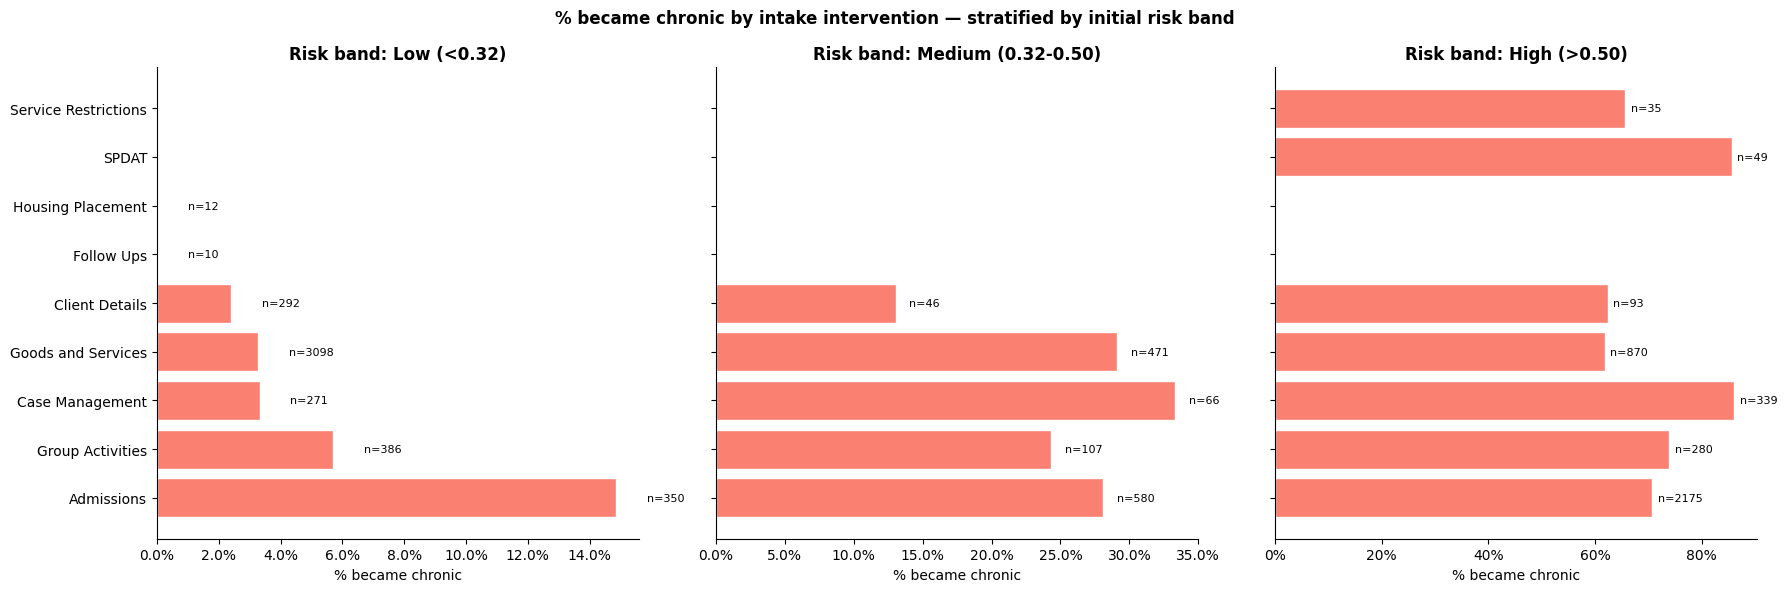

In [8]:
# ── Same analysis stratified by risk band
strat = (
    df.groupby(['risk_band', 'first_intervention_type'])
    .agg(
        n=('became_chronic', 'count'),
        pct_chronic=('became_chronic', 'mean'),
    )
    .reset_index()
)

# Grouped bar chart by risk band
bands = strat['risk_band'].cat.categories.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, band in zip(axes, bands):
    data = strat[strat['risk_band'] == band].sort_values('pct_chronic', ascending=False)
    data = data[data['n'] >= 10]
    bars = ax.barh(data['first_intervention_type'], data['pct_chronic'],
                   color='salmon', edgecolor='white')
    ax.set_xlabel('% became chronic')
    ax.set_title(f'Risk band: {band}', fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'n={row["n"]}', va='center', fontsize=8)

plt.suptitle('% became chronic by intake intervention — stratified by initial risk band', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Beating the Odds

**Base:** Only clients with score > 0.50 from Model 1 — i.e., clients who at intake had a high probability of becoming chronically homeless.

Within that high-risk group we split into two subgroups:
- **High risk + NEVER became chronic ✅** → clients the model flagged as high risk who ultimately avoided chronicity
- **High risk + DID become chronic ❌** → clients the model flagged as high risk who did become chronic

**Question:** What intervention did clients at intake have — those who avoided chronicity vs those who did not?  
The table shows how interventions are distributed within each group — each column sums to 100%.

In [9]:
# ── Filter high-risk group
high_risk = df[df['risk_score'] > 0.50].copy()

n_total    = len(high_risk)
n_success  = (high_risk['became_chronic'] == 0).sum()
n_chronic  = (high_risk['became_chronic'] == 1).sum()

print('Clients with high probability of chronicity (score > 0.50):')
print()
print(f'  {"Group":<45} {"N":>6}  {"%" :>6}')
print(f'  {"-"*60}')
print(f'  {"High risk + NEVER became chronic ✅":<45} {n_success:>6}  {n_success/n_total:>6.1%}')
print(f'  {"High risk + DID become chronic ❌":<45} {n_chronic:>6}  {n_chronic/n_total:>6.1%}')
print(f'  {"-"*60}')
print(f'  {"Total high risk":<45} {n_total:>6}  {"100.0%":>6}')
print()
print(f'  → Out of every 10 high-risk clients, {n_success/n_total*10:.0f} avoided chronicity and {n_chronic/n_total*10:.0f} did become chronic.')

Clients with high probability of chronicity (score > 0.50):

  Group                                              N       %
  ------------------------------------------------------------
  High risk + NEVER became chronic ✅              1147   29.8%
  High risk + DID become chronic ❌                2703   70.2%
  ------------------------------------------------------------
  Total high risk                                 3850  100.0%

  → Out of every 10 high-risk clients, 3 avoided chronicity and 7 did become chronic.


Intake intervention distribution — Clients with high probability of chronicity (score > 0.50):
                         NEVER became chronic ✅  DID become chronic ❌  Mean risk score
first_intervention_type                                                               
Admissions                                 55.4                  56.9         0.773773
Case Management                             4.1                  10.8         0.868809
Client Details                              3.1                   2.1         0.691773
Follow Ups                                  0.1                   0.0         0.513299
Goods and Services                         28.9                  19.9         0.712211
Group Activities                            6.4                   7.7         0.767572
Housing Placement                           0.3                   0.0         0.667243
Housing Retention                           0.0                   0.1         0.910389
SPDAT                              

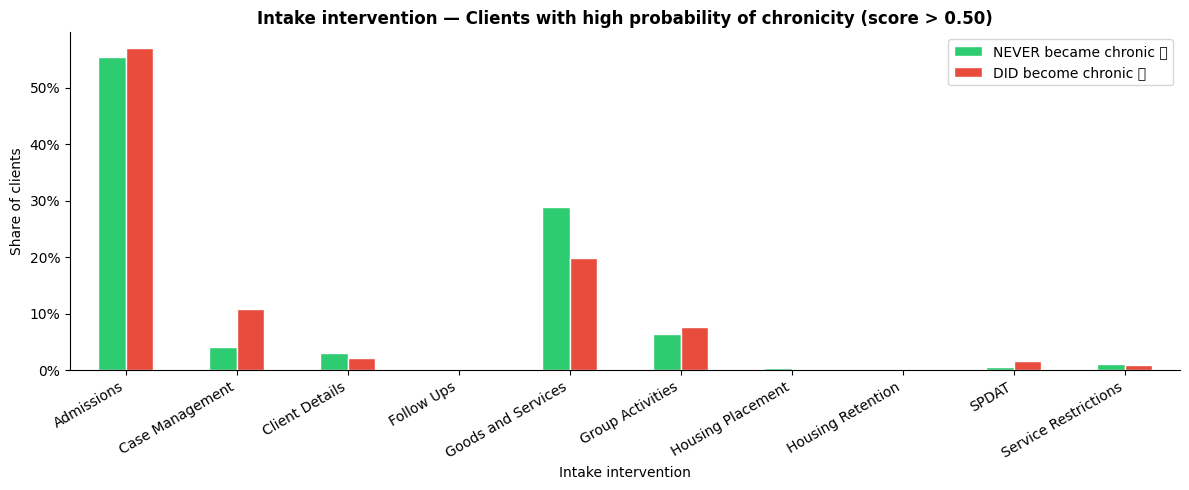

In [10]:
# ── Compare first_intervention_type between the two groups (high risk only)
group_success = high_risk[high_risk['became_chronic'] == 0]['first_intervention_type'].value_counts(normalize=True)
group_chronic  = high_risk[high_risk['became_chronic'] == 1]['first_intervention_type'].value_counts(normalize=True)
risk_medio     = high_risk.groupby('first_intervention_type')['risk_score'].mean()

comparison = pd.DataFrame({
    'NEVER became chronic ✅': group_success,
    'DID become chronic ❌':   group_chronic,
    'Mean risk score':          risk_medio,
}).fillna(0)

print('Intake intervention distribution — Clients with high probability of chronicity (score > 0.50):')
print((comparison * 100).round(1).assign(**{'Mean risk score': comparison['Mean risk score']}).to_string())

# Chart
comparison[['NEVER became chronic ✅', 'DID become chronic ❌']].plot(
    kind='bar', figsize=(12, 5), color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('Intake intervention — Clients with high probability of chronicity (score > 0.50)', fontweight='bold')
plt.xlabel('Intake intervention')
plt.ylabel('Share of clients')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

Days in system by group — Clients with high probability of chronicity (score > 0.50):
                         count   mean    std  min   25%    50%    75%    max
Group                                                                       
DID become chronic ❌    2703.0  311.9  285.1  0.0  31.0  213.0  578.0  790.0
NEVER became chronic ✅  1147.0  147.5  174.2  0.0  31.0   89.0  182.0  790.0


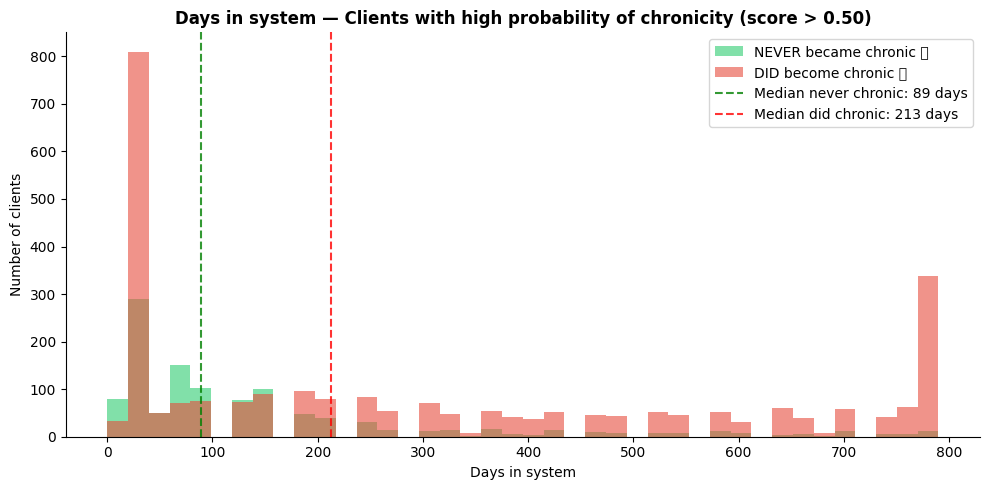

In [11]:
# ── Compare time_in_system between the two groups
print('Days in system by group — Clients with high probability of chronicity (score > 0.50):')
high_risk_display = high_risk.copy()
high_risk_display['Group'] = high_risk_display['became_chronic'].map({
    0: 'NEVER became chronic ✅',
    1: 'DID become chronic ❌'
})
print(high_risk_display.groupby('Group')['time_in_system'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
success_times = high_risk[high_risk['became_chronic'] == 0]['time_in_system'].dropna()
chronic_times  = high_risk[high_risk['became_chronic'] == 1]['time_in_system'].dropna()

ax.hist(success_times, bins=40, alpha=0.6, color='#2ecc71', label='NEVER became chronic ✅')
ax.hist(chronic_times,  bins=40, alpha=0.6, color='#e74c3c', label='DID become chronic ❌')
ax.axvline(success_times.median(), color='green', linestyle='--', alpha=0.8,
           label=f'Median never chronic: {success_times.median():.0f} days')
ax.axvline(chronic_times.median(),  color='red',   linestyle='--', alpha=0.8,
           label=f'Median did chronic: {chronic_times.median():.0f} days')
ax.set_xlabel('Days in system')
ax.set_ylabel('Number of clients')
ax.set_title('Days in system — Clients with high probability of chronicity (score > 0.50)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Full Intervention Trajectory

For each client, we build the sequence of interventions across all their snapshots.

In [12]:
# ── Build intervention trajectory per client
trajectory = (
    cam.sort_values(['Dummy Client ID', 'Date'])
    .groupby('Dummy Client ID')['Recent Interaction Module']
    .agg(list)
    .reset_index()
    .rename(columns={'Recent Interaction Module': 'trajectory'})
)

# Trajectory metrics
def count_unique(lst):
    return pd.Series(lst).dropna().nunique()

def most_frequent(lst):
    s = pd.Series(lst).dropna()
    return s.mode()[0] if len(s) > 0 else None

def last_intervention(lst):
    s = pd.Series(lst).dropna()
    return s.iloc[-1] if len(s) > 0 else None

def changed_intervention(lst):
    s = pd.Series(lst).dropna()
    return int(s.nunique() > 1) if len(s) > 0 else 0

trajectory['n_distinct_interventions'] = trajectory['trajectory'].apply(count_unique)
trajectory['most_frequent_intervention'] = trajectory['trajectory'].apply(most_frequent)
trajectory['last_intervention']          = trajectory['trajectory'].apply(last_intervention)
trajectory['changed_intervention']       = trajectory['trajectory'].apply(changed_intervention)
trajectory['n_snapshots']                = trajectory['trajectory'].apply(len)

# Merge with main dataframe
df = df.merge(
    trajectory.drop(columns=['trajectory']),
    on='Dummy Client ID',
    how='left'
)

print(f'Trajectory built for {len(trajectory):,} clients')
print(f'\nAverage snapshots per client: {df["n_snapshots"].mean():.1f}')
print(f'Clients who changed intervention: {df["changed_intervention"].mean():.1%}')

Trajectory built for 10,118 clients

Average snapshots per client: 6.1
Clients who changed intervention: 21.1%


Trajectory metrics — Clients with high probability of chronicity (score > 0.50):
                        changed_intervention  n_distinct_interventions  \
NEVER became chronic ✅                  0.23                      1.29   
DID become chronic ❌                    0.41                      1.68   

                        n_snapshots  
NEVER became chronic ✅         4.98  
DID become chronic ❌          10.06  


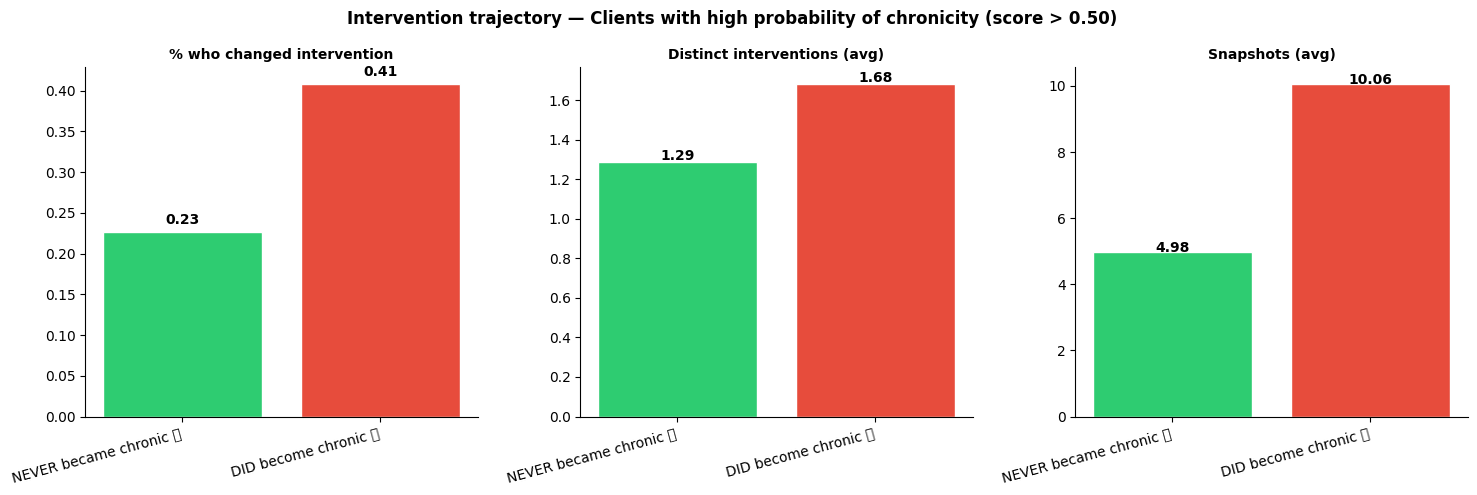

In [13]:
# ── Compare trajectory metrics — HIGH RISK group
# Redefine high_risk now that df has trajectory columns
high_risk = df[df['risk_score'] > 0.50].copy()

traj_cols = ['changed_intervention', 'n_distinct_interventions', 'n_snapshots']

print('Trajectory metrics — Clients with high probability of chronicity (score > 0.50):')
traj_summary = high_risk.groupby('became_chronic')[traj_cols].mean().round(2)
traj_summary.index = ['NEVER became chronic ✅', 'DID become chronic ❌']
print(traj_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['NEVER became chronic ✅', 'DID become chronic ❌']
colors = ['#2ecc71', '#e74c3c']

for ax, col, title in zip(axes, traj_cols,
    ['% who changed intervention', 'Distinct interventions (avg)', 'Snapshots (avg)']):
    vals = [high_risk[high_risk['became_chronic']==0][col].mean(),
            high_risk[high_risk['became_chronic']==1][col].mean()]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontweight='bold')

plt.suptitle('Intervention trajectory — Clients with high probability of chronicity (score > 0.50)', fontweight='bold')
plt.tight_layout()
plt.show()

Last recorded intervention — Clients with high probability of chronicity (score > 0.50):
                      NEVER became chronic ✅  DID become chronic ❌  Mean risk score
last_intervention                                                                  
Admissions                              44.6                  46.8         0.772097
Case Management                          6.1                  16.6         0.831058
Client Details                           2.2                   1.0         0.673779
Follow Ups                               0.0                   0.0         0.773196
Goods and Services                      31.3                  20.2         0.723209
Group Activities                        13.3                  13.1         0.768677
Housing Placement                        0.3                   0.1         0.725016
Housing Retention                        0.2                   0.1         0.836387
SPDAT                                    0.8                   0.9     

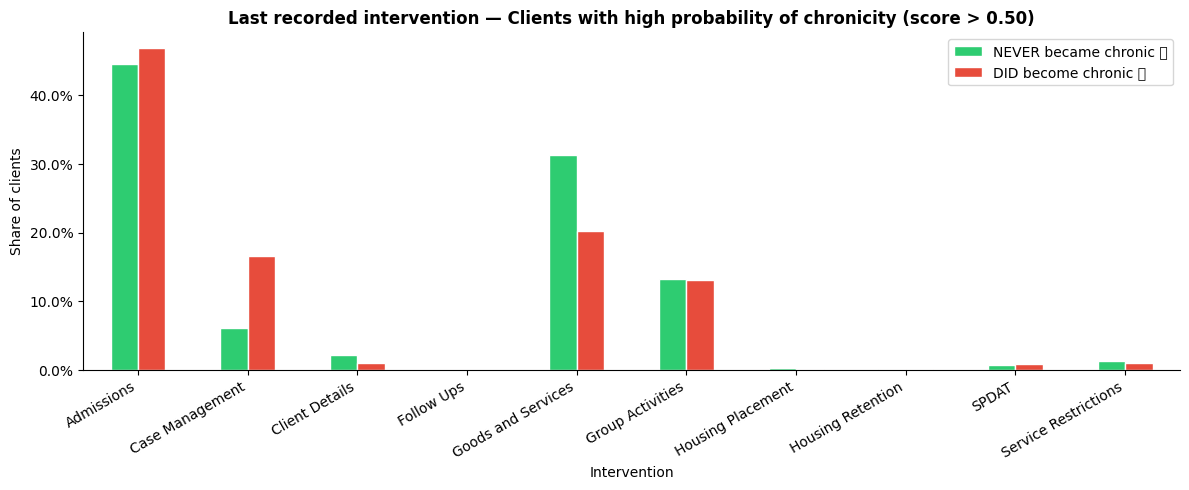

In [14]:
# ── Last intervention before leaving the system — HIGH RISK group
last_success = high_risk[high_risk['became_chronic']==0]['last_intervention'].value_counts(normalize=True)
last_chronic  = high_risk[high_risk['became_chronic']==1]['last_intervention'].value_counts(normalize=True)
risk_medio    = high_risk.groupby('last_intervention')['risk_score'].mean()

last_comp = pd.DataFrame({
    'NEVER became chronic ✅': last_success,
    'DID become chronic ❌':   last_chronic,
    'Mean risk score':          risk_medio,
}).fillna(0)

print('Last recorded intervention — Clients with high probability of chronicity (score > 0.50):')
print((last_comp * 100).round(1).assign(**{'Mean risk score': last_comp['Mean risk score']}).to_string())

last_comp[['NEVER became chronic ✅', 'DID become chronic ❌']].plot(
    kind='bar', figsize=(12, 5), color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('Last recorded intervention — Clients with high probability of chronicity (score > 0.50)', fontweight='bold')
plt.xlabel('Intervention')
plt.ylabel('Share of clients')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

## 6. Most Common Transitions

What intervention sequences (A → B) are most frequent in clients with good vs bad outcomes?

In [15]:
# ── Calculate transitions (consecutive pairs) per client
def get_transitions(lst):
    s = pd.Series(lst).dropna().tolist()
    return [(s[i], s[i+1]) for i in range(len(s)-1) if s[i] != s[i+1]]

trajectory['transitions'] = trajectory['trajectory'].apply(get_transitions)

# Merge with outcome
traj_with_outcome = trajectory.merge(
    df[['Dummy Client ID', 'became_chronic', 'risk_score']],
    on='Dummy Client ID',
    how='left'
)

# Explode transitions and count by outcome
def build_transition_table(group_df, label):
    all_trans = [t for lst in group_df['transitions'] for t in lst]
    if not all_trans:
        return pd.DataFrame()
    counts = pd.Series(all_trans).value_counts().head(15).reset_index()
    counts.columns = ['Transition', f'Frequency ({label})']
    counts['Transition'] = counts['Transition'].apply(lambda x: f'{x[0]} → {x[1]}')
    return counts

# High-risk group
hr_success = traj_with_outcome[(traj_with_outcome['risk_score'] > 0.50) & (traj_with_outcome['became_chronic'] == 0)]
hr_chronic  = traj_with_outcome[(traj_with_outcome['risk_score'] > 0.50) & (traj_with_outcome['became_chronic'] == 1)]

trans_success = build_transition_table(hr_success, 'NEVER became chronic ✅')
trans_chronic  = build_transition_table(hr_chronic,  'DID become chronic ❌')

print('Top 10 transitions — NEVER became chronic (high probability of chronicity, score > 0.50):')
print(trans_success.head(10).to_string(index=False))
print()
print('Top 10 transitions — DID become chronic (high probability of chronicity, score > 0.50):')
print(trans_chronic.head(10).to_string(index=False))

Top 10 transitions — NEVER became chronic (high probability of chronicity, score > 0.50):
                           Transition  Frequency (NEVER became chronic ✅)
      Admissions → Goods and Services                                  88
        Admissions → Group Activities                                  58
      Goods and Services → Admissions                                  53
         Admissions → Case Management                                  36
Goods and Services → Group Activities                                  29
    Admissions → Service Restrictions                                  18
 Case Management → Goods and Services                                  12
   Case Management → Group Activities                                  12
        Group Activities → Admissions                                  10
         Case Management → Admissions                                   9

Top 10 transitions — DID become chronic (high probability of chronicity, score > 0.50):
       

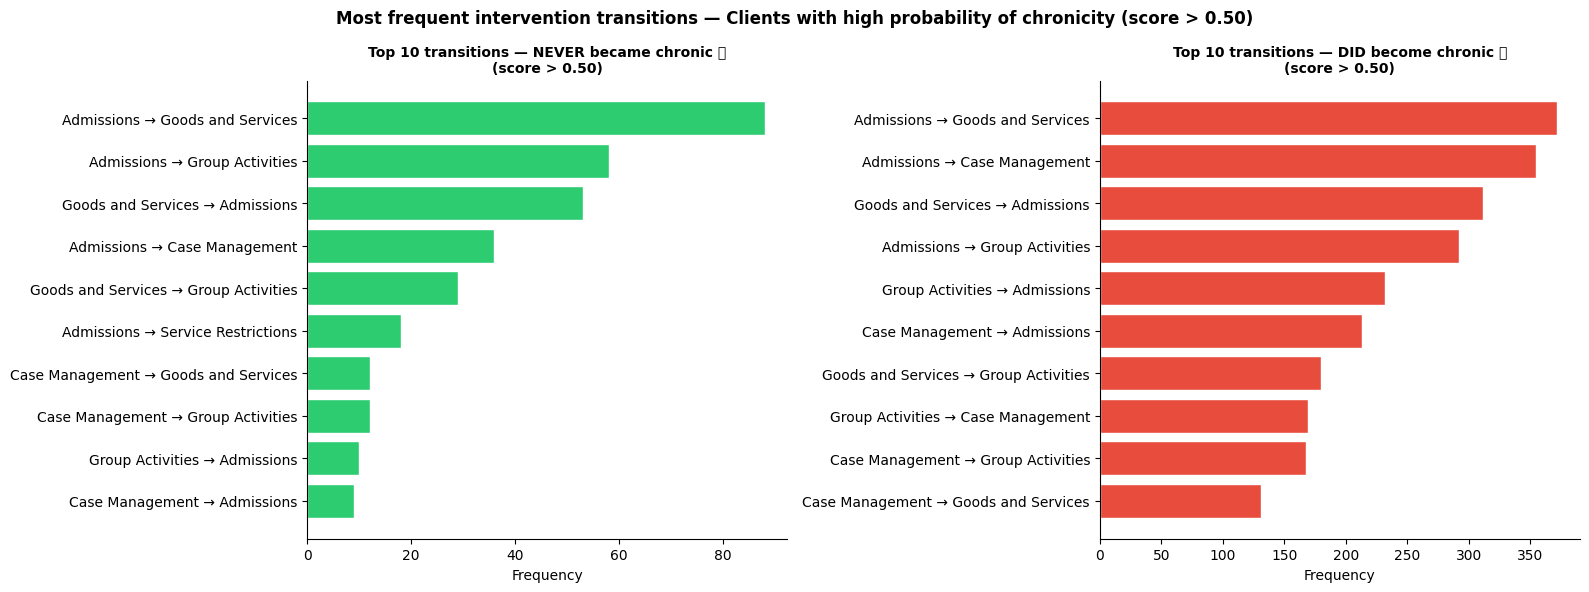

In [16]:
# ── Transition chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in zip(
    axes,
    [trans_success.head(10), trans_chronic.head(10)],
    ['Top 10 transitions — NEVER became chronic ✅\n(score > 0.50)',
     'Top 10 transitions — DID become chronic ❌\n(score > 0.50)'],
    ['#2ecc71', '#e74c3c']
):
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        continue
    col = data.columns[1]
    ax.barh(data['Transition'][::-1], data[col][::-1], color=color, edgecolor='white')
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.suptitle('Most frequent intervention transitions — Clients with high probability of chronicity (score > 0.50)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Final Table by Intake Intervention

Summary of % of clients who never became chronic, by intake intervention.

In [17]:
# ── Final table: by intake intervention
final_table = (
    df.groupby('first_intervention_type')
    .agg(
        n_clients=('became_chronic', 'count'),
        mean_risk_score=('risk_score', 'mean'),
        pct_success_a=('success_a', 'mean'),
    )
    .sort_values('pct_success_a', ascending=False)
    .reset_index()
)

display_table = final_table.copy()
display_table['mean_risk_score'] = display_table['mean_risk_score'].map('{:.3f}'.format)
display_table['pct_success_a']   = display_table['pct_success_a'].map('{:.1%}'.format)
display_table.columns = ['Intake intervention', 'N clients', 'Mean risk score',
                          '% Never became chronic']
print('Final table by intake intervention:')
print(display_table.to_string(index=False))

Final table by intake intervention:
 Intake intervention  N clients Mean risk score % Never became chronic
          Follow Ups         12           0.190                  91.7%
      Client Details        431           0.210                  83.5%
  Goods and Services       4439           0.216                  82.5%
   Housing Placement         22           0.281                  72.7%
   Housing Retention         10           0.401                  70.0%
    Group Activities        773           0.392                  67.0%
     Case Management        676           0.514                  52.2%
          Admissions       3105           0.646                  43.5%
Service Restrictions         46           0.662                  43.5%
               SPDAT         62           0.737                  29.0%


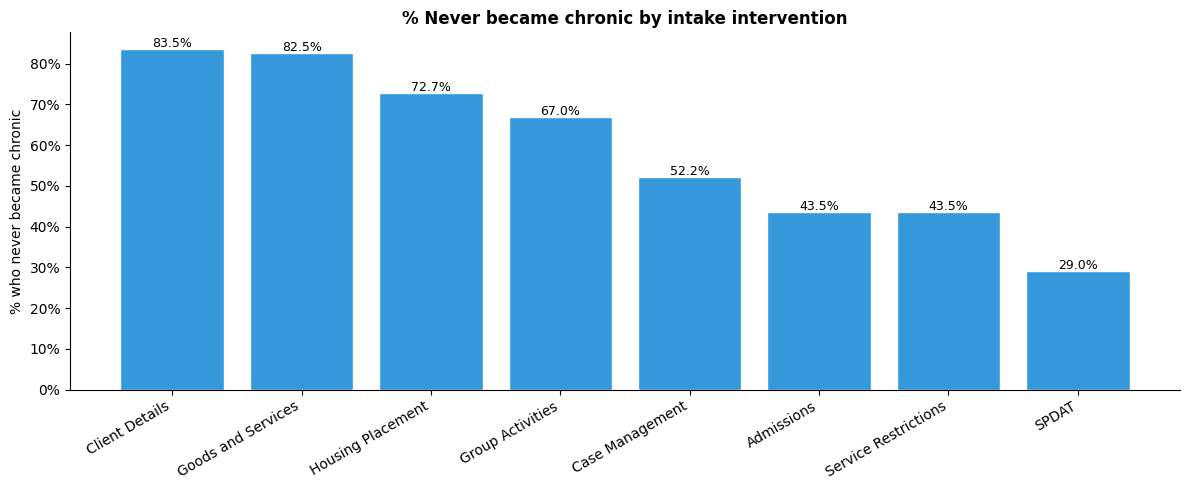

Note: only interventions with n ≥ 20 clients are shown.


In [18]:
# ── Chart: % never became chronic by intake intervention
plot_data = final_table[final_table['n_clients'] >= 20].copy()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(plot_data)), plot_data['pct_success_a'],
              color='#3498db', edgecolor='white')

ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data['first_intervention_type'], rotation=30, ha='right')
ax.set_ylabel('% who never became chronic')
ax.set_title('% Never became chronic by intake intervention', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["pct_success_a"]:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('Note: only interventions with n ≥ 20 clients are shown.')

## 8. Summary of Findings

> ⚠️ **Important disclaimer:** This analysis shows descriptive patterns — which interventions were present when clients had good outcomes. **We cannot claim that those interventions caused the good outcome.** Observational data does not allow establishing causality. This analysis is a guide for exploring hypotheses, not definitive proof of effectiveness.

In [19]:
# ── Automated summary of main findings
print('=' * 75)
print('SUMMARY OF FINDINGS — 06_intervention_outcomes.ipynb')
print('=' * 75)

print(f'\n📊 Full dataset: {len(df):,} valid clients')
print(f'   Became chronic at some point:  {df["became_chronic"].mean():.1%}')
print(f'   Never became chronic:          {(1-df["became_chronic"].mean()):.1%}')

# ── Table 1: high-risk groups
n_total   = len(high_risk)
n_success = (high_risk['became_chronic'] == 0).sum()
n_chronic = (high_risk['became_chronic'] == 1).sum()

print(f'\n🔍 Clients with high probability of chronicity at intake (score > 0.50):')
print(f'   {"Group":<52} {"N":>6}  {"%":>6}')
print(f'   {"-"*67}')
print(f'   {"High risk + NEVER became chronic ✅":<52} {n_success:>6}  {n_success/n_total:>6.1%}')
print(f'   {"High risk + DID become chronic ❌":<52} {n_chronic:>6}  {n_chronic/n_total:>6.1%}')
print(f'   {"-"*67}')
print(f'   {"Total high risk":<52} {n_total:>6}  {"100.0%":>6}')

# ── Table 2: INTAKE intervention — sorted by NEVER became chronic ✅ descending
group_success = high_risk[high_risk['became_chronic'] == 0]['first_intervention_type'].value_counts(normalize=True)
group_chronic  = high_risk[high_risk['became_chronic'] == 1]['first_intervention_type'].value_counts(normalize=True)
risk_medio     = high_risk.groupby('first_intervention_type')['risk_score'].mean()

comparison = pd.DataFrame({
    'never_chronic': group_success,
    'chronic':       group_chronic,
    'mean_risk':     risk_medio,
}).fillna(0)
comparison['difference'] = comparison['never_chronic'] - comparison['chronic']
comparison = comparison.sort_values('never_chronic', ascending=False)

print(f'\n📋 INTAKE intervention by group — HIGH RISK clients (score > 0.50):')
print(f'   (sorted by "NEVER became chronic ✅" descending)')
print(f'   {"Intervention":<25} {"NEVER became chronic ✅":>26} {"DID become chronic ❌":>26} {"Difference":>11} {"Mean risk":>10}')
print(f'   {"-"*100}')
for interv, row in comparison.iterrows():
    dif_str = f'+{row["difference"]*100:.1f}%' if row['difference'] > 0 else f'{row["difference"]*100:.1f}%'
    print(f'   {interv:<25} {row["never_chronic"]:>26.1%} {row["chronic"]:>26.1%} {dif_str:>11} {row["mean_risk"]:>10.3f}')

# ── Table 3: LAST intervention — sorted by NEVER became chronic ✅ descending
last_success = high_risk[high_risk['became_chronic']==0]['last_intervention'].value_counts(normalize=True)
last_chronic  = high_risk[high_risk['became_chronic']==1]['last_intervention'].value_counts(normalize=True)
risk_ultimo   = high_risk.groupby('last_intervention')['risk_score'].mean()

last_comp = pd.DataFrame({
    'never_chronic': last_success,
    'chronic':       last_chronic,
    'mean_risk':     risk_ultimo,
}).fillna(0)
last_comp = last_comp.sort_values('never_chronic', ascending=False)

print(f'\n📋 LAST recorded intervention by group — HIGH RISK clients (score > 0.50):')
print(f'   (sorted by "NEVER became chronic ✅" descending)')
print(f'   {"Intervention":<25} {"NEVER became chronic ✅":>26} {"DID become chronic ❌":>26} {"Mean risk":>10}')
print(f'   {"-"*90}')
for interv, row in last_comp.iterrows():
    print(f'   {interv:<25} {row["never_chronic"]:>26.1%} {row["chronic"]:>26.1%} {row["mean_risk"]:>10.3f}')

print(f'\n💡 Key takeaways:')
print(f'')
print(f'   AT INTAKE (intervention at first contact):')
print(f'   • Goods and Services (+9 pts): notably more frequent in clients who NEVER')
print(f'     became chronic (28.9% vs 19.9%).')
print(f'   • Client Details (+0.9 pts): small favourable difference.')
print(f'   • Group Activities (-1.3 pts): slightly more frequent in clients who DID')
print(f'     become chronic — small but present.')
print(f'   • Case Management (-6.7 pts): much more frequent in clients who DID become')
print(f'     chronic — but their mean risk (0.869) is the highest, confirming it is')
print(f'     assigned to the most vulnerable cases (selection bias).')
print(f'')
print(f'   AT EXIT (last recorded intervention):')
print(f'   • Admissions: most frequent in both groups, no meaningful difference.')
print(f'   • Goods and Services (+11 pts): more frequent in clients who NEVER became')
print(f'     chronic (31.3% vs 20.2%) — consistent signal with intake.')
print(f'   • Group Activities (+0.2 pts): minimal difference, no clear signal.')
print(f'   • Client Details (+1.2 pts): small favourable difference at exit.')
print(f'   • Case Management (-10.5 pts): much more frequent in clients who DID become')
print(f'     chronic at exit (16.6% vs 6.1%) — reflects that the hardest cases remain')
print(f'     in intensive intervention until the end.')

print(f'\n⚠️  Caveat: This analysis shows associations, not causality.')
print(f'   Differences may reflect the initial risk profile,')
print(f'   not the direct effect of interventions.')
print('=' * 75)

SUMMARY OF FINDINGS — 06_intervention_outcomes.ipynb

📊 Full dataset: 9,576 valid clients
   Became chronic at some point:  34.0%
   Never became chronic:          66.0%

🔍 Clients with high probability of chronicity at intake (score > 0.50):
   Group                                                     N       %
   -------------------------------------------------------------------
   High risk + NEVER became chronic ✅                     1147   29.8%
   High risk + DID become chronic ❌                       2703   70.2%
   -------------------------------------------------------------------
   Total high risk                                        3850  100.0%

📋 INTAKE intervention by group — HIGH RISK clients (score > 0.50):
   (sorted by "NEVER became chronic ✅" descending)
   Intervention                  NEVER became chronic ✅       DID become chronic ❌  Difference  Mean risk
   ----------------------------------------------------------------------------------------------------
  